<a href="https://colab.research.google.com/github/Naman80070/GenAI-GFG/blob/main/MNIST_Fashion_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [13]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Load CSV Files from Colab

In [4]:
train_df = pd.read_csv("/fashion-mnist_test.csv")
test_df  = pd.read_csv("/fashion-mnist_test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(10000, 785)
(10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Separate Features and Labels

In [6]:
# Labels
y_train = train_df.iloc[:, 0]
y_test  = test_df.iloc[:, 0]

# Pixel values
X_train = train_df.iloc[:, 1:]
X_test  = test_df.iloc[:, 1:]

# Normalize Pixel Values

*   Pixel range = 0–255 → convert to 0–1



In [7]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Convert to NumPy (Keras friendly)

In [8]:
X_train = X_train.values
X_test  = X_test.values
y_train = y_train.values
y_test  = y_test.values

# Build High-Accuracy ANN Model

In [10]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.2),

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model + Validation Accuracy

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6048 - loss: 1.1366 - val_accuracy: 0.7690 - val_loss: 0.5898
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7954 - loss: 0.5657 - val_accuracy: 0.8280 - val_loss: 0.4664
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8345 - loss: 0.4689 - val_accuracy: 0.8330 - val_loss: 0.4396
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8415 - loss: 0.4470 - val_accuracy: 0.8490 - val_loss: 0.4078
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8517 - loss: 0.4042 - val_accuracy: 0.8530 - val_loss: 0.3837
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8696 - loss: 0.3744 - val_accuracy: 0.8610 - val_loss: 0.3885
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8810 - loss: 0.3274 - val_accuracy: 0.8720 - val_loss: 0.3569
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8807 - loss: 0.3226 - val_accuracy: 0.8580 - v

# Check Test Accuracy

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8888 - loss: 0.2908
Test Accuracy: 0.8877999782562256


# Plot Training vs Validation Accuracy

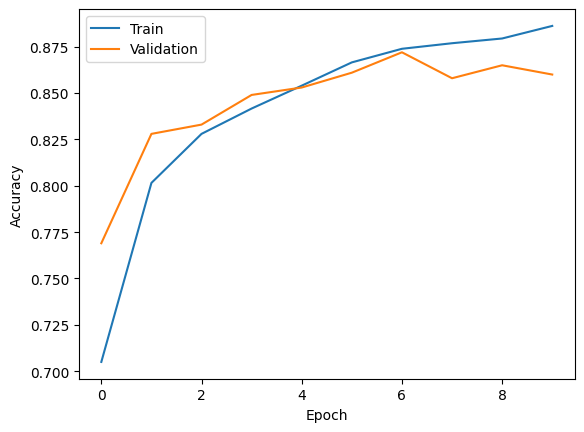

In [14]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Using CNN Model for better accuracy ---------------------------------------->

# Split Features & Labels

In [15]:
x_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

x_test  = test_df.iloc[:, 1:].values
y_test  = test_df.iloc[:, 0].values

# Normalize + Reshape for CNN

In [16]:
x_train = x_train / 255.0
x_test  = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(10000, 28, 28, 1)


# Convert Labels to One-Hot

In [17]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# CNN Model

In [18]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten

model = Sequential([

    # Conv Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    # Conv Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Conv Block 3
    Conv2D(128, (3,3), activation='relu'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [20]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.4489 - loss: 1.5162 - val_accuracy: 0.7580 - val_loss: 0.6640
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7457 - loss: 0.6907 - val_accuracy: 0.7860 - val_loss: 0.5528
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.7756 - loss: 0.6131 - val_accuracy: 0.8105 - val_loss: 0.4757
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8019 - loss: 0.5347 - val_accuracy: 0.8270 - val_loss: 0.4429
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8199 - loss: 0.4779 - val_accuracy: 0.8420 - val_loss: 0.4065
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.8240 - loss: 0.4547 - val_accuracy: 0.8485 - val_loss: 0.3884
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8507 - loss: 0.4063 - val_accuracy: 0.8595 - val_loss: 0.3775
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8565 - loss: 0.3879 - val_

# Test Accuracy

In [21]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8970 - loss: 0.2635
Test Accuracy: 0.8956000208854675


# Plot Accuracy & Loss Together

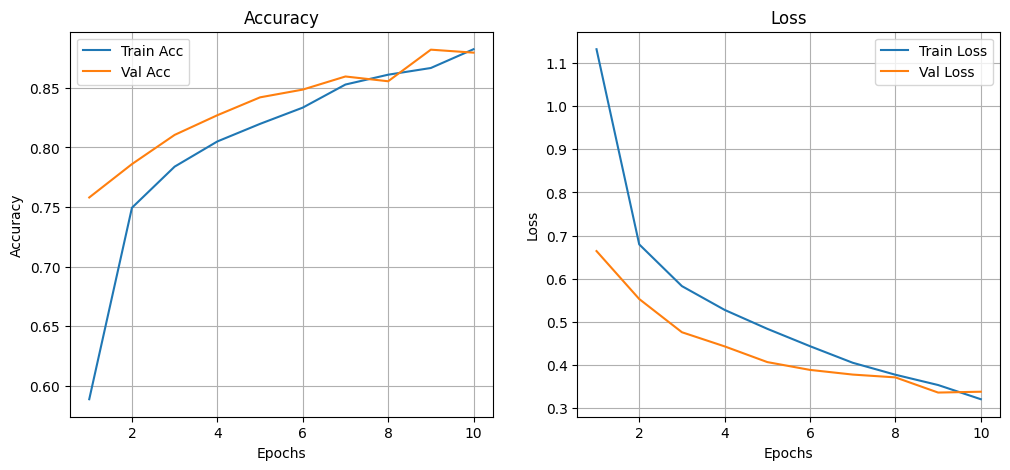

In [22]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12,5))

# ---- Accuracy subplot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ---- Loss subplot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()